In [41]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, List, Dict, Literal
from operator import add
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode
# from langgraph.types import Send
import random

In [42]:
class State(TypedDict):
    recruited_knights : Annotated[List[str],add, "Knights which are going to fight in the favour of Ser Duncan The Tall."]
    armors : Annotated[List[str], add]
    plan : str

In [43]:
def dummy_supervisor(state: State) -> State:
    return {}
def supervisor_node(state: State) -> Literal["recruiter_agent", "armorer_agent", "plan_node", "__end__"]:
    recruited_knights = state.get("recruited_knights", [])
    armors = state.get("armors", [])
    plan = state.get("plan", "")
    
    if len(recruited_knights) < 6:
        return "recruiter_agent"
    if len(armors) < len(recruited_knights): # Fixed
        return "armorer_agent"
    if not plan:                             # Fixed
        return "plan_node"
    return "__end__"

In [44]:
def recruited_node(state: State) -> State:
    knights_ = state.get("recruited_knights", [])
    knights = ["knight-01", "knight-02", "knight-03", "knight-04", "knight-05", "knight-06"]
    knight = random.choice(knights)
    
    if knight not in knights_:
        return {"recruited_knights": [knight]}
    return {"recruited_knights": []} # Safe skip

In [45]:
@tool(description="Tool used to forge valyrian steel armors")
def forge_steel_armor():
    choice = random.random()
    if choice < 0.5:
        raise ValueError("Out of Valyrian Steel!")
    return f"steel-{round(choice, 2)}"

# To catch the fallback properly, this tool must share the EXACT name 
# that the ToolNode was originally asked to call.
@tool(description="Boiled leather fallback.")
def fallback_leather_forge():
    return "boiled-leather"

# Create the nodes and bind the fallback exactly as requested
primary_armorer_node = ToolNode([forge_steel_armor])
fallback_armorer_node = ToolNode([fallback_leather_forge])

tool_node_with_fallback = primary_armorer_node.with_fallbacks([fallback_armorer_node])

# --- 3. The Armorer Agent Wrapper ---
def armorer_agent(state: State):
    """Tricks the ToolNode by feeding it a mock LLM message, then extracts the result."""
    
    # 1. Create a fake AIMessage with a tool call
    mock_state = {
        "messages": [
            AIMessage(
                content="", 
                tool_calls=[{"name": "forge_steel_armor", "args": {}, "id": "call_123"}]
            )
        ]
    }
    
    # 2. Invoke the ToolNode (if it fails, it hits the fallback automatically)
    result = tool_node_with_fallback.invoke(mock_state)
    
    # 3. ToolNode returns a ToolMessage. Extract the content and update our real state!
    armor_created = result["messages"][-1].content
    return {"armors": [armor_created]}

In [46]:
def plan_node(state: State) -> State:
    return {"plan" : "The plan is ready"}

In [47]:
builder = StateGraph(State)
builder.add_node("supervisor", dummy_supervisor)
builder.add_node("recruiter", recruited_node)
builder.add_node("armorer", armorer_agent)
builder.add_node("plan", plan_node)

builder.add_edge(START, "supervisor")
builder.add_conditional_edges("supervisor", supervisor_node, {
    "recruiter_agent" : "recruiter", 
    "armorer_agent" : "armorer",
    "plan_node" : "plan",
    "__end__": END
})
builder.add_edge("recruiter", "supervisor")
builder.add_edge("armorer", "supervisor")
builder.add_edge("plan", "supervisor")

graph = builder.compile()

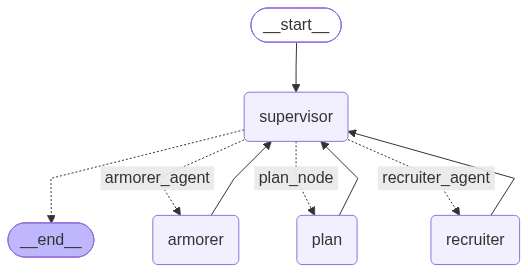

In [48]:
graph